Метод простого симплекса: Тестирование на трёх функциях

=== Тест 1: Розенброк ===

Тестирование функции: Розенброк
Начальная точка: [-2.0, -2.0]
Результат: [0.6410349916386413, 0.40625344319779594]
Значение функции: 0.13103902557727926
Количество итераций: 519
Количество точек траектории: 519


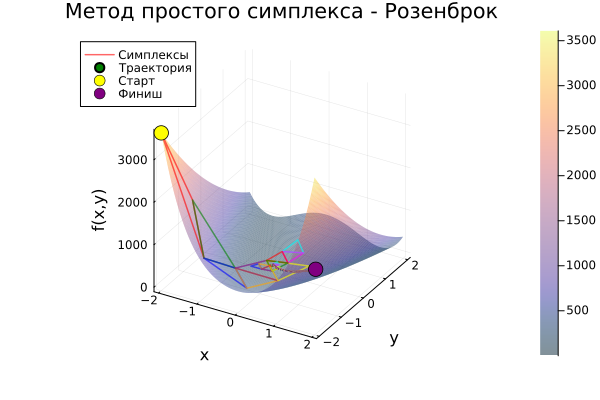

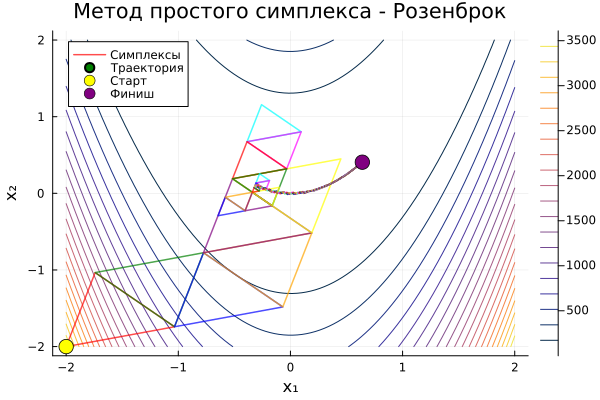


=== Тест 2: Растригин ===

Тестирование функции: Растригин
Начальная точка: [0.5, 0.5]
Результат: [0.9953913151905143, 2.982748069345673]
Значение функции: 9.950474354673851
Количество итераций: 34
Количество точек траектории: 34


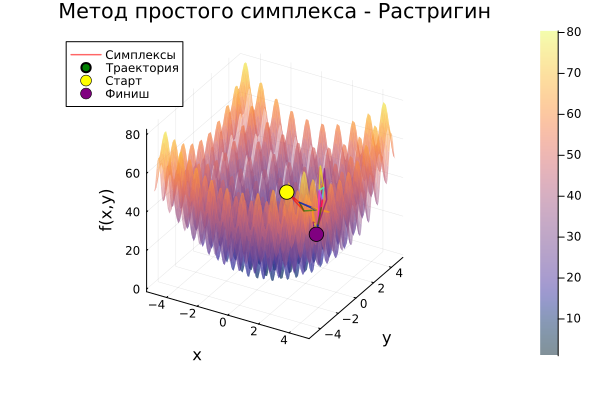

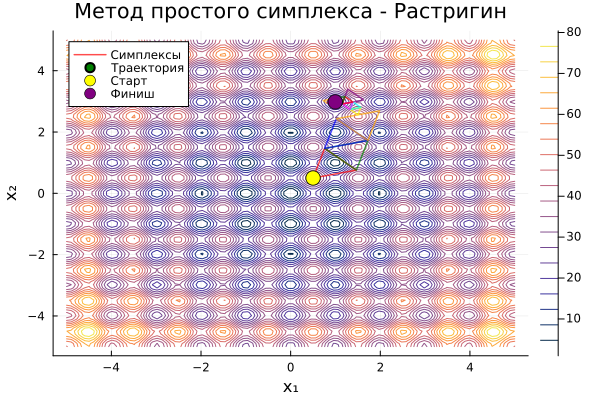


=== Тест 3: Швефель ===

Тестирование функции: Швефель
Начальная точка: [0.5, 0.5]
Результат: [5.2373290692295935, 5.240091205093604]
Значение функции: 830.0751976163613
Количество итераций: 40
Количество точек траектории: 40


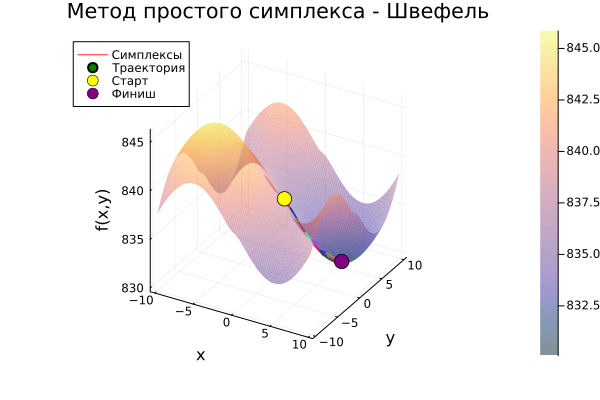

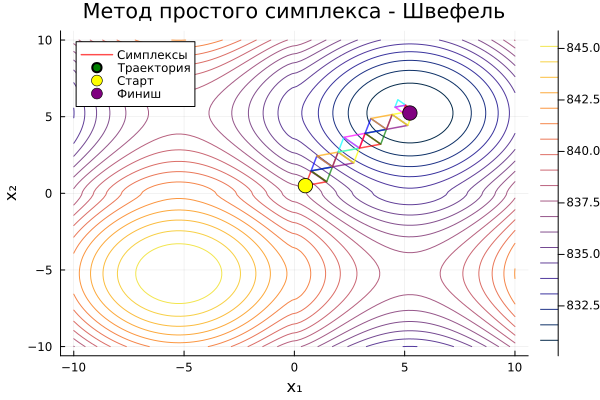

([5.2373290692295935, 5.240091205093604], [[0.5, 0.5], [1.724744871391589, 1.724744871391589], [1.0176380902050415, 2.4318516525781364], [1.9835639164941097, 2.6906706976806567], [2.690670697680657, 1.9835639164941092], [2.9494897427831774, 2.9494897427831774], [2.24238296159663, 3.656596523969725], [3.208308787885698, 3.915415569072245], [3.9154155690722456, 3.2083087878856977], [4.174234614174766, 4.174234614174766]  …  [5.230793785606641, 5.241842329062681], [5.245886376642408, 5.245886376642408], [5.236318057334662, 5.236318057334662], [5.230793785606642, 5.241842329062683], [5.237329069229593, 5.240091205093604], [5.236318057334662, 5.236318057334662], [5.240091205093604, 5.2373290692295935], [5.241102216988535, 5.241102216988535], [5.238710137161599, 5.238710137161599], [5.2373290692295935, 5.240091205093604]], Plot{Plots.GRBackend() n=44}, Plot{Plots.GRBackend() n=44})

In [7]:
# 14 53 - 3 балла
using Plots
using LinearAlgebra

gr()

# Тестовые функции
function rosenbrock(x)
    return (1.0 - x[1])^2 + 100.0*(x[2] - x[1]^2)^2
end

function rastrigin(x)
    n = length(x)
    return 20 + sum(x[i]^2 - 10*cos(2*pi*x[i]) for i in 1:n)
end

function schwefel(x)
    n = length(x)
    return 418.9829*n - sum(x[i]*sin(sqrt(abs(x[i]))) for i in 1:n)
end

# Функция для создания начального симплекса
function create_initial_simplex(x0, n, alpha=1.0)
    # Создаем правильный симплекс с центром в x0
    # Для n-мерного пространства нужно n+1 точка
    simplex = [copy(x0)]
    
    # Используем стандартный способ создания правильного симплекса
    # Основан на правильном симплексе с единичной длиной ребра
    q = (sqrt(n+1) - 1) / (n * sqrt(2))
    p = q + 1 / sqrt(2)
    
    for i in 1:n
        x_new = copy(x0)
        for j in 1:n
            if j == i
                x_new[j] += alpha * p
            else
                x_new[j] += alpha * q
            end
        end
        push!(simplex, x_new)
    end
    
    return simplex
end

# Метод простого симплекса для R^n (не Нельдер-Мид!)
function simplex_method(f, x0, eps=1e-3, alpha=1.0, max_iterations=5000)
    n = length(x0)
    simplex = create_initial_simplex(x0, n, alpha)
    
    # Траектории для визуализации
    trajectory = [copy(x0)]
    all_simplexes = [copy(simplex)]
    
    iteration = 0
    
    while iteration < max_iterations
        iteration += 1
        
        if norm(simplex[1] - simplex[2]) < eps
            break
        end
        
        # Вычисляем значения функции
        vals = f.(simplex)
        worst_idx = argmax(vals)
        
        # Меняем местами худшую и первую точку
        simplex[1], simplex[worst_idx] = simplex[worst_idx], simplex[1]
        
        # Отражение (как в PDF: x4 = points[2] + points[3] - points[1])
        x_reflected = simplex[2] .+ simplex[3] .- simplex[1]
        f_reflected = f(x_reflected)
        f_good = f(simplex[2])
        f_better = f(simplex[3])
        
        if f_reflected >= f_good && f_reflected >= f_better
            # Отражение не лучше - сжимаем к x_reflected
            simplex[1] = x_reflected
            simplex[2] = x_reflected .+ (simplex[2] .- x_reflected) ./ 2
            simplex[3] = x_reflected .+ (simplex[3] .- x_reflected) ./ 2
            push!(trajectory, copy(x_reflected))
        else
            # Отражение лучше - принимаем его
            simplex[1] = x_reflected
            push!(trajectory, copy(x_reflected))
        end
        
        # Сохраняем симплекс для визуализации
        push!(all_simplexes, copy(simplex))
    end
    
    # Возвращаем лучшую точку (первая точка после сортировки)
    result = simplex[1]
    
    return result, trajectory, all_simplexes, iteration
end

# Функция для создания 3D визуализации (для 2D и 3D)
function plot_simplex_3d(f, x0, result, trajectory, all_simplexes, title_str, x_range, y_range, n)
    if n == 2
        # 2D случай: рисуем треугольники
        x_grid = range(x_range[1], x_range[2], length=100)
        y_grid = range(y_range[1], y_range[2], length=100)
        X = repeat(reshape(x_grid, 1, :), length(y_grid), 1)
        Y = repeat(y_grid, 1, length(x_grid))
        Z = map((a,b) -> f([a,b]), X, Y)
        
        plt = surface(x_grid, y_grid, Z, color=:thermal, alpha=0.5, legend=true)
        
        # Рисуем треугольники симплексов
        colors = [:red, :green, :blue, :orange, :purple, :yellow, :cyan, :magenta]
        for (idx, simplex) in enumerate(all_simplexes)
            if length(simplex) >= 3
                color = colors[(idx-1) % length(colors) + 1]
                # Треугольник из первых 3 точек
                x_coords = [simplex[1][1], simplex[2][1], simplex[3][1], simplex[1][1]]
                y_coords = [simplex[1][2], simplex[2][2], simplex[3][2], simplex[1][2]]
                z_coords = [f(simplex[1]), f(simplex[2]), f(simplex[3]), f(simplex[1])]
                plot!(plt, x_coords, y_coords, z_coords, linecolor=color, linewidth=1.5, 
                      label=(idx == 1 ? "Симплексы" : ""), alpha=0.6)
            end
        end
        
        # Траектория (прореживаем для производительности)
        if length(trajectory) > 1
            step_traj = max(1, length(trajectory) ÷ 1)  # Максимум 500 точек
            trajectory_filtered = trajectory[1:step_traj:end]
            scatter3d!(plt, 
                [p[1] for p in trajectory_filtered], 
                [p[2] for p in trajectory_filtered], 
                [f(p) for p in trajectory_filtered], 
                color=:green, 
                markersize=2,
                label="Траектория"
            )
        end
        
        # Начальная и конечная точки
        scatter3d!(plt, [x0[1]], [x0[2]], [f(x0)], color=:yellow, markersize=8, label="Старт")
        scatter3d!(plt, [result[1]], [result[2]], [f(result)], color=:purple, markersize=8, label="Финиш")
        
        title!(plt, title_str)
        xlabel!(plt, "x")
        ylabel!(plt, "y")
        zlabel!(plt, "f(x,y)")
        
    elseif n == 3
        # 3D случай: рисуем только траекторию и точки (без поверхности функции)
        plt = plot3d(legend=true)
        
        # Траектория (прореживаем)
        if length(trajectory) > 1
            step_traj = max(1, length(trajectory) ÷ 1)  # Максимум 500 точек
            trajectory_filtered = trajectory[1:step_traj:end]
            scatter3d!(plt, 
                [p[1] for p in trajectory_filtered], 
                [p[2] for p in trajectory_filtered], 
                [p[3] for p in trajectory_filtered], 
                color=:green, 
                markersize=3,
                label="Траектория"
            )
        end
        
        # Начальная и конечная точки
        scatter3d!(plt, [x0[1]], [x0[2]], [x0[3]], color=:yellow, markersize=8, label="Старт")
        scatter3d!(plt, [result[1]], [result[2]], [result[3]], color=:purple, markersize=8, label="Финиш")
        
        title!(plt, title_str)
        xlabel!(plt, "x₁")
        ylabel!(plt, "x₂")
        zlabel!(plt, "x₃")
    else
        # n > 3: только траектория в 3D проекции
        plt = plot3d(legend=true)
        
        if length(trajectory) > 1
            scatter3d!(plt, 
                [p[1] for p in trajectory], 
                [p[2] for p in trajectory], 
                [length(p) > 2 ? p[3] : 0.0 for p in trajectory], 
                color=:green, 
                markersize=4,
                label="Траектория (проекция)"
            )
        end
        
        scatter3d!(plt, [x0[1]], [x0[2]], [length(x0) > 2 ? x0[3] : 0.0], color=:yellow, markersize=8, label="Старт")
        scatter3d!(plt, [result[1]], [result[2]], [length(result) > 2 ? result[3] : 0.0], color=:purple, markersize=8, label="Финиш")
        
        title!(plt, title_str)
        xlabel!(plt, "x₁")
        ylabel!(plt, "x₂")
        zlabel!(plt, "x₃ (проекция)")
    end
    
    return plt
end

# Функция для создания 2D контурного графика (только для n=2)
function plot_simplex_2d(f, x0, result, trajectory, all_simplexes, title_str, x_range, y_range, n)
    if n != 2
        # Для n != 2 возвращаем пустой график или проекцию
        plt = plot(title=title_str * " (только для 2D)")
        return plt
    end
    
    x_grid = range(x_range[1], x_range[2], length=100)
    y_grid = range(y_range[1], y_range[2], length=100)
    X = repeat(reshape(x_grid, 1, :), length(y_grid), 1)
    Y = repeat(y_grid, 1, length(x_grid))
    Z = map((a,b) -> f([a,b]), X, Y)
    
    plt = contour(x_grid, y_grid, Z, 
        color=:thermal, 
        levels=20,
        xlabel="x₁", 
        ylabel="x₂",
        title=title_str,
        legend=:topleft
    )
    
    # Рисуем треугольники симплексов
    colors = [:red, :green, :blue, :orange, :purple, :yellow, :cyan, :magenta]
    for (idx, simplex) in enumerate(all_simplexes)
        if length(simplex) >= 3
            color = colors[(idx-1) % length(colors) + 1]
            x_coords = [simplex[1][1], simplex[2][1], simplex[3][1], simplex[1][1]]
            y_coords = [simplex[1][2], simplex[2][2], simplex[3][2], simplex[1][2]]
            plot!(plt, x_coords, y_coords, color=color, linewidth=1.5, 
                  label=(idx == 1 ? "Симплексы" : ""), alpha=0.7)
        end
    end
    
    # Траектория (прореживаем для производительности)
    if length(trajectory) > 0
        step_traj = max(1, length(trajectory) ÷ 1)  # Максимум 500 точек
        trajectory_filtered = trajectory[1:step_traj:end]
        scatter!(plt, 
            [p[1] for p in trajectory_filtered], 
            [p[2] for p in trajectory_filtered], 
            color=:green, 
            markersize=2,
            label="Траектория"
        )
    end
    
    # Начальная и конечная точки
    scatter!(plt, [x0[1]], [x0[2]], color=:yellow, markersize=8, label="Старт")
    scatter!(plt, [result[1]], [result[2]], color=:purple, markersize=8, label="Финиш")
    
    plot!(plt, colorbar=true)
    
    return plt
end

# Основная функция для тестирования
function test_simplex(f, f_name, x0, x_range, y_range, n, show_plots=true)
    println("\n" * "="^60)
    println("Тестирование функции: $f_name")
    println("Начальная точка: $x0")
    println("="^60)
    
    result, trajectory, all_simplexes = simplex_method(f, x0)
    
    println("Результат: $result")
    println("Значение функции: $(f(result))")
    println("Количество итераций: $(length(all_simplexes))")
    println("Количество точек траектории: $(length(trajectory))")
    
    # Создание графиков
    title_3d = "Метод простого симплекса - $f_name"
    title_2d = "Метод простого симплекса - $f_name"
    
    plt_3d = plot_simplex_3d(f, x0, result, trajectory, all_simplexes, title_3d, x_range, y_range, n)
    plt_2d = plot_simplex_2d(f, x0, result, trajectory, all_simplexes, title_2d, x_range, y_range, n)
    
    # Отображение графиков сразу после вывода текста
    if show_plots
        display(plt_3d)
        if n == 2
            display(plt_2d)
        end
    end
    
    return result, trajectory, plt_3d, plt_2d
end

# Запуск тестов
println("Метод простого симплекса: Тестирование на трёх функциях")

# Тест 1: Розенброк (2D)
println("\n=== Тест 1: Розенброк ===")
x0_rosenbrock_2d = [-2.0, -2.0]
result_r1, traj_r1, plt_3d_r1, plt_2d_r1 = test_simplex(rosenbrock, "Розенброк", x0_rosenbrock_2d, (-2.0, 2.0), (-2.0, 2.0), 2)

# Тест 2: Растригин (2D)
println("\n=== Тест 2: Растригин ===")
x0_rastrigin_2d = [0.5, 0.5]
result_r2, traj_r2, plt_3d_r2, plt_2d_r2 = test_simplex(rastrigin, "Растригин", x0_rastrigin_2d, (-5.0, 5.0), (-5.0, 5.0), 2)

# Тест 3: Швефель (2D)
println("\n=== Тест 3: Швефель ===")
x0_schwefel_2d = [0.5, 0.5]
result_r3, traj_r3, plt_3d_r3, plt_2d_r3 = test_simplex(schwefel, "Швефель", x0_schwefel_2d, (-10.0, 10.0), (-10.0, 10.0), 2)